In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv('NASS_Bee-Colony_2015-2021.csv', low_memory=False)
df = df.dropna()

In [52]:
# Replacing NA values with np.nan and change the data types for multiple columns
cols = ['Starting Colonies','Maximum Colonies', 'Lost Colonies', 'Percent Loss', 'Added Colonies', 'Renovated Colonies','Percent Renovated']
df[cols] = df[cols].replace(['(NA)', '(X)', '(Z)'], np.nan)
df[cols] = df[cols].apply(pd.to_numeric)
print(df.dtypes)

State                     str
Starting Colonies     float64
Maximum Colonies      float64
Lost Colonies         float64
Percent Loss          float64
Added Colonies        float64
Renovated Colonies    float64
Percent Renovated     float64
Year                      str
dtype: object


In [53]:
missing_value = df.isna().sum()
print(missing_value)

State                   0
Starting Colonies      47
Maximum Colonies       72
Lost Colonies          47
Percent Loss           53
Added Colonies         47
Renovated Colonies     48
Percent Renovated     176
Year                    0
dtype: int64


In [54]:
#Statistics for each columns
print(df.describe().round(2))

       Starting Colonies  Maximum Colonies  Lost Colonies  Percent Loss  \
count            1175.00           1150.00        1175.00       1169.00   
mean           123280.66          79157.18       16970.03         11.59   
std            436620.40         190428.43       61636.84          7.31   
min              1300.00           1300.00           0.00          0.00   
25%              8000.00           9000.00         965.00          7.00   
50%             17500.00          21000.00        2200.00         10.00   
75%             55000.00          68000.00        7000.00         15.00   
max           3181180.00        1710000.00      502350.00         65.00   

       Added Colonies  Renovated Colonies  Percent Renovated  
count         1175.00             1174.00            1046.00  
mean         16660.37            14309.23               8.31  
std          66416.13            60490.39               9.60  
min              0.00                0.00               0.00  
25%      

In [55]:
df_states = df[df['State'] != "United States"].copy()
cols = ['Starting Colonies','Maximum Colonies', 'Lost Colonies', 'Percent Loss', 'Added Colonies', 'Renovated Colonies','Percent Renovated']
df_states[cols] = df[cols].apply(pd.to_numeric)
print(df_states.dtypes)


State                     str
Starting Colonies     float64
Maximum Colonies      float64
Lost Colonies         float64
Percent Loss          float64
Added Colonies        float64
Renovated Colonies    float64
Percent Renovated     float64
Year                      str
dtype: object


In [56]:
# Computing loss rate
df_states['loss_rate'] = np.where(df_states['Maximum Colonies'] > 0, (df_states['Lost Colonies']/df_states['Maximum Colonies']) *100, np.nan)

In [57]:
correlation = df_states['loss_rate'].corr(df_states['Percent Loss'].astype(float))
print(correlation)

0.9992694357551082


In [58]:
## What year was the loss rate at its worst?
national_by_year = (
    df_states
    .groupby('Year')['loss_rate']
    .mean()
    .reset_index()
    .rename(columns={'loss_rate': 'mean_loss_rate'})
    .sort_values('mean_loss_rate', ascending=False)
)


In [59]:
print("── National average colony loss rate by year ─────────────────")
print("   (Mean of all states, all quarters, that year)")
print()
print(national_by_year.to_string(index=False))

worst_year  = national_by_year.iloc[0]['Year']
worst_rate  = national_by_year.iloc[0]['mean_loss_rate']

# Filter out NaN values for 'mean_loss_rate' before finding the best year
best_year_df = national_by_year.dropna(subset=['mean_loss_rate'])
best_year   = best_year_df.iloc[-1]['Year']
best_rate   = best_year_df.iloc[-1]['mean_loss_rate']

print(f"\nWorst year : {int(worst_year.split('-')[0])}  ({worst_rate:.1f}% average loss)")
print(f"Best year  : {int(best_year.split('-')[0])}  ({best_rate:.1f}% average loss)")

── National average colony loss rate by year ─────────────────
   (Mean of all states, all quarters, that year)

   Year  mean_loss_rate
2015-Q1       17.873458
2018-Q1       16.336649
2017-Q1       15.067906
2016-Q1       13.708796
2018-Q4       13.401562
2019-Q1       12.471777
2017-Q3       12.377837
2021-Q1       12.374606
2017-Q4       12.111237
2020-Q3       11.829793
2019-Q4       11.748686
2020-Q1       11.393801
2015-Q3       11.291367
2018-Q3       11.071137
2019-Q3       11.057842
2016-Q3       11.044359
2016-Q4       10.977075
2020-Q4       10.945867
2015-Q4       10.220849
2018-Q2        8.773723
2015-Q2        8.684905
2016-Q2        8.548234
2020-Q2        8.123941
2021-Q2        8.103456
2017-Q2        7.064345
2019-Q2             NaN

Worst year : 2015  (17.9% average loss)
Best year  : 2017  (7.1% average loss)


In [60]:
# What states with the worst/best loss rate?
state_avg = (
    df_states
    .groupby('State')['loss_rate']
    .mean()
    .reset_index()
    .rename(columns={'loss_rate': 'mean_loss_rate'})
    .sort_values('mean_loss_rate', ascending=False)
)

In [61]:
print("── Average colony loss rate by state (2015–2022) ─────────────")
print()
print("Top 10 worst states:")
print(state_avg.head(10).to_string(index=False))

print("\nTop 10 best states (lowest loss):")
print(state_avg.tail(10).to_string(index=False))



── Average colony loss rate by state (2015–2022) ─────────────

Top 10 worst states:
     State  mean_loss_rate
    Kansas       19.541289
   Arizona       17.898271
New Mexico       17.503328
      Ohio       15.248331
   Alabama       15.177438
 Tennessee       15.158042
  Kentucky       14.803106
  Illinois       14.659223
  Arkansas       14.493338
  Colorado       14.245654

Top 10 best states (lowest loss):
       State  mean_loss_rate
South Dakota        8.811382
    Nebraska        8.737830
   Louisiana        7.701999
      Oregon        7.370361
North Dakota        7.193329
 Connecticut        7.127959
     Montana        5.938209
  New Jersey        5.571466
     Vermont        5.413375
      Hawaii        5.274100


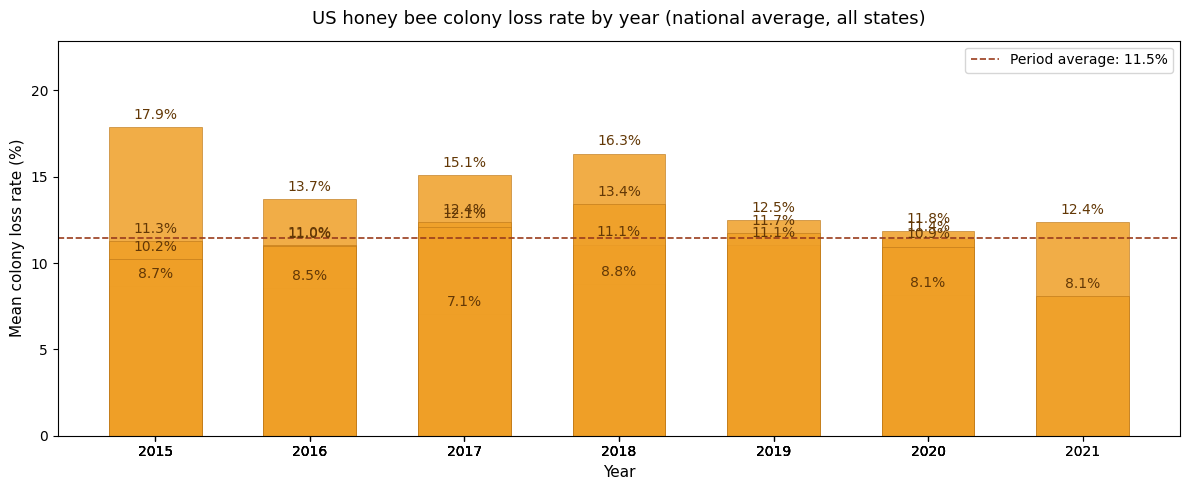

In [62]:
# CHART 1: National loss rate by year
national_by_year_sorted = national_by_year.sort_values('Year')

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    national_by_year_sorted['Year'].apply(lambda x: int(x.split('-')[0])),
    national_by_year_sorted['mean_loss_rate'],
    color='#EF9F27',    # Amber — fits the bee theme
    width=0.6,
    alpha=0.85,
    edgecolor='#BA7517',
    linewidth=0.5,
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x = centre of bar
        height + 0.3,                         # y = just above bar
        f'{height:.1f}%',                     # text = formatted value
        ha='center', va='bottom',
        fontsize=10, color='#633806',
    )

# Add a reference line at the overall mean
overall_mean = national_by_year_sorted['mean_loss_rate'].mean()
ax.axhline(overall_mean, color='#993C1D', linestyle='--',
           linewidth=1.2, label=f'Period average: {overall_mean:.1f}%')

ax.set_title('US honey bee colony loss rate by year (national average, all states)',
             fontsize=13, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean colony loss rate (%)', fontsize=11)
ax.set_xticks(national_by_year_sorted['Year'].apply(lambda x: int(x.split('-')[0])))
ax.legend(fontsize=10)
ax.set_ylim(0, national_by_year_sorted['mean_loss_rate'].max() + 5)

plt.tight_layout()
plt.savefig('day1_loss_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

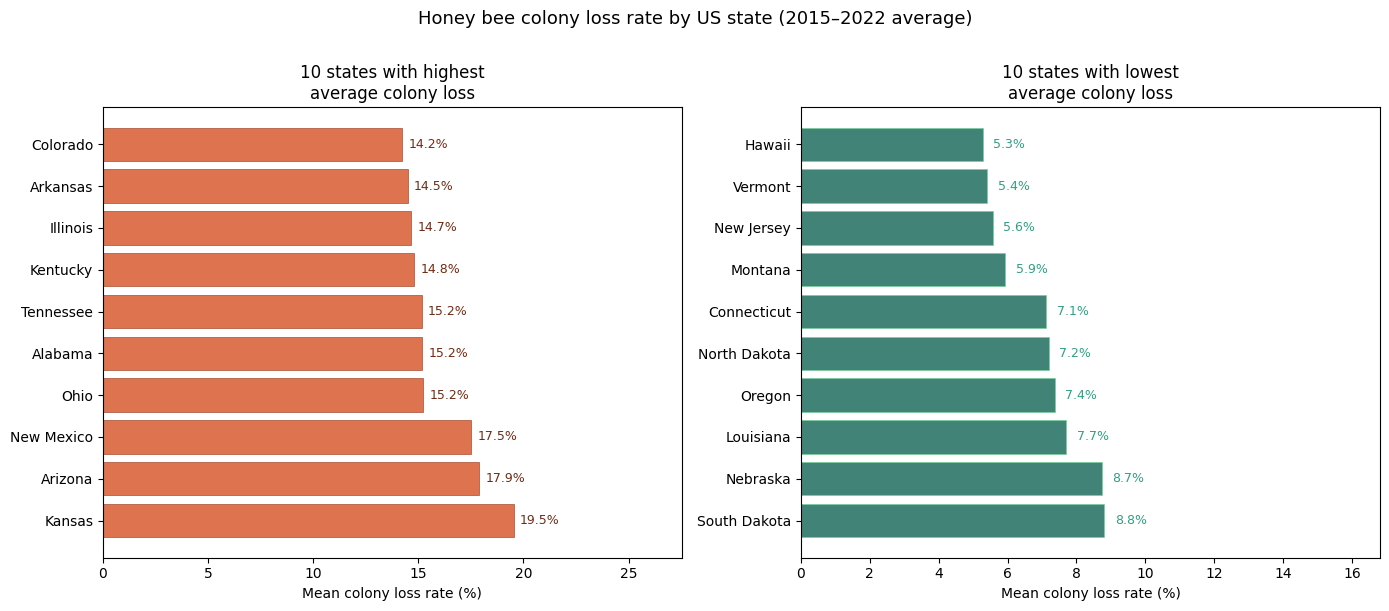

In [63]:
# CHART 2: Loss rate by states
worst_10_states = state_avg.head(10)
best_10_states = state_avg.tail(10)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(
    worst_10_states['State'],
    worst_10_states['mean_loss_rate'],
    color = '#D85A30',
    alpha  = 0.85,
    edgecolor='#993C1D',
    linewidth=0.5,
)
for i, (val, name) in enumerate(zip(worst_10_states['mean_loss_rate'],
                                     worst_10_states['State'])):
    ax1.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9,
             color='#712B13')

ax1.set_title('10 states with highest\naverage colony loss', fontsize=12)
ax1.set_xlabel('Mean colony loss rate (%)')
ax1.set_xlim(0, worst_10_states['mean_loss_rate'].max() + 8)

ax2.barh(
    best_10_states["State"],
    best_10_states["mean_loss_rate"],
    color = '#1F6F5F',
    alpha = 0.85,
    edgecolor = '#6FCF97',
    linewidth=0.5,
)
for i, (val, name) in enumerate(zip(best_10_states['mean_loss_rate'],
                                     best_10_states['State'])):
  ax2.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9,color = '#2FA084')
ax2.set_title('10 states with lowest\naverage colony loss', fontsize=12)
ax2.set_xlabel('Mean colony loss rate (%)')
ax2.set_xlim(0, best_10_states['mean_loss_rate'].max() + 8)
plt.suptitle('Honey bee colony loss rate by US state (2015–2022 average)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('day1_loss_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

##Handling NA values

In [64]:
missing_value = df_states.isna().sum()
missing_pct = (missing_value/len(df)*100).round(1)
print(missing_pct)

State                  0.0
Starting Colonies      3.8
Maximum Colonies       3.8
Lost Colonies          3.8
Percent Loss           4.3
Added Colonies         3.8
Renovated Colonies     3.8
Percent Renovated     14.3
Year                   0.0
loss_rate              3.8
dtype: float64


In [65]:
df_clean = df_states.copy()

In [66]:
core_cols = ['Maximum Colonies', 'Percent Loss', 'loss_rate', 'Starting Colonies']
existing_core = [c for c in core_cols if c in df_clean.columns]
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=existing_core)
rows_dropped = rows_before - len(df_clean)

In [67]:
activity_cols = ['Added Colonies', 'Renovated Colonies', 'Pecent Renovated']
for col in activity_cols:
    if col in df_clean.columns:
        n_filled = df_clean[col].isna().sum()
        df_clean[col] = df_clean[col].fillna(0)
        if n_filled > 0:
            print(f"Filled {n_filled} missing values in '{col}' with 0")


Filled 1 missing values in 'Renovated Colonies' with 0


In [68]:
remaining = df_clean[existing_core].isna().sum()
print(remaining.to_string())

Maximum Colonies     0
Percent Loss         0
loss_rate            0
Starting Colonies    0


##Seasonal Analysis

In [69]:
print(df_clean["Year"].unique())
df_clean['quarter_label'] = df_clean['Year'].str.strip().str[-2:]
print(df_clean["quarter_label"].unique())

<StringArray>
['2015-Q1', '2015-Q2', '2015-Q3', '2015-Q4', '2016-Q1', '2016-Q2', '2016-Q3',
 '2016-Q4', '2017-Q1', '2017-Q2', '2017-Q3', '2017-Q4', '2018-Q1', '2018-Q2',
 '2018-Q3', '2018-Q4', '2019-Q1', '2019-Q3', '2019-Q4', '2020-Q1', '2020-Q2',
 '2020-Q3', '2020-Q4', '2021-Q1', '2021-Q2']
Length: 25, dtype: str
<StringArray>
['Q1', 'Q2', 'Q3', 'Q4']
Length: 4, dtype: str


In [70]:
Season_mapping = {
    'Q1': 'Winter',
    'Q2': 'Spring',
    'Q3': 'Summer',
    'Q4': 'Fall'
}
df_clean['Season'] = df_clean['quarter_label'].map(Season_mapping)
df_clean.head()


,State,Starting Colonies,Maximum Colonies,Lost Colonies,Percent Loss,Added Colonies,Renovated Colonies,Percent Renovated,Year,loss_rate,quarter_label,Season
0,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,Q1,Winter
1,Arizona,35000.0,35000.0,4600.0,13.0,3400.0,2100.0,6.0,2015-Q1,13.142857,Q1,Winter
2,Arkansas,13000.0,14000.0,1500.0,11.0,1200.0,90.0,1.0,2015-Q1,10.714286,Q1,Winter
3,California,1440000.0,1690000.0,255000.0,15.0,250000.0,124000.0,7.0,2015-Q1,15.088757,Q1,Winter
4,Colorado,3500.0,12500.0,1500.0,12.0,200.0,140.0,1.0,2015-Q1,12.000000,Q1,Winter


In [71]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Calculate the mean and standard deviation of loss rate for each Season
seasonal_stats = (
    df_clean.groupby('Season')['loss_rate']
    .agg(['mean', 'std', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_loss_rate', 'std': 'std_loss_rate'})
)

# Convert the 'Season' column to a Categorical type with the defined order
seasonal_stats['Season'] = pd.Categorical(seasonal_stats['Season'], categories=season_order, ordered=True)

# Sort the DataFrame by the ordered 'Season' for chronological display
seasonal_stats = seasonal_stats.sort_values('Season')

print("Seasonal colony loss rate statistics ")
print(seasonal_stats.to_string(index=False))
print()

# Find the worst and best seasons based on 'mean_loss_rate'
# Sort by mean_loss_rate to identify highest/lowest
worst_season_df = seasonal_stats.sort_values('mean_loss_rate', ascending=False)
worst_season = worst_season_df.iloc[0]['Season']
best_season = worst_season_df.iloc[-1]['Season']

print(f"Highest average loss: {worst_season}")
print(f"Lowest average loss : {best_season}")

Seasonal colony loss rate statistics 
Season  mean_loss_rate  std_loss_rate    median  count
Winter       14.350696       9.321414 12.727273    318
Spring        8.245193       5.464726  7.647059    275
Summer       11.445389       6.062143 10.529825    276
  Fall       11.608819       6.284100 11.000000    275

Highest average loss: Winter
Lowest average loss : Spring


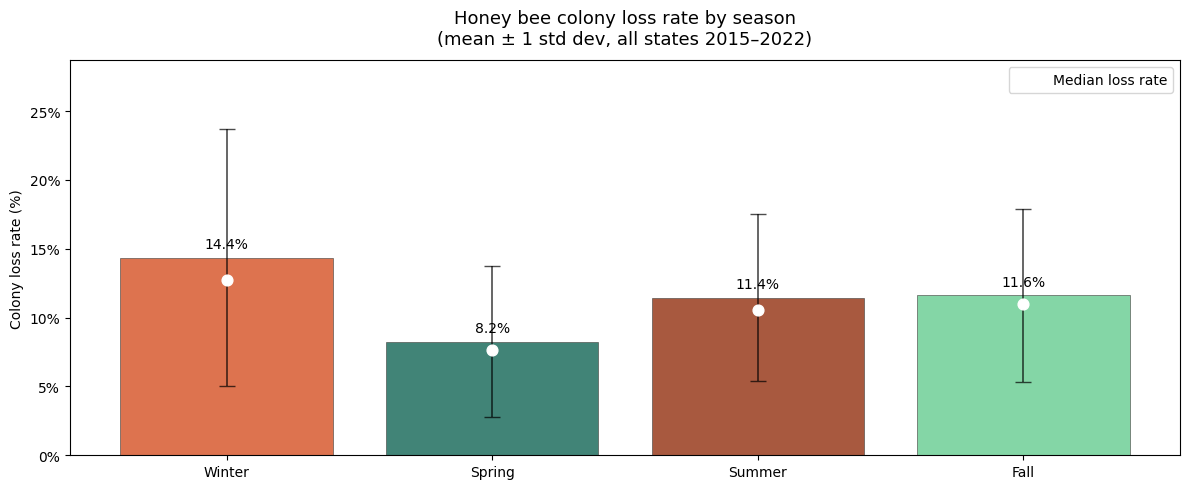

In [72]:
import matplotlib.ticker as mticker

Season_color = {
    'Winter' : '#D85A30',
    'Spring' : '#1F6F5F',
    'Summer' : '#993C1D',
    'Fall'   : '#6FCF97'
}
fig, ax = plt.subplots(figsize=(12,5))
colors = [Season_color[s] for s in seasonal_stats['Season']]

bars = ax.bar(
    seasonal_stats['Season'],
    seasonal_stats['mean_loss_rate'],
    yerr=seasonal_stats['std_loss_rate'],    # Error bars = ± 1 standard deviation, Corrected column name
    color=colors,
    alpha=0.85,
    edgecolor='#444441',
    linewidth=0.5,
    capsize=6,
    error_kw={'linewidth': 1.2, 'alpha': 0.7},
)


ax.scatter(
    seasonal_stats['Season'],
    seasonal_stats['median'],
    color='white', s=60, zorder=5,
    label='Median loss rate',
)

# Add mean value labels above each bar
for bar, val in zip(bars, seasonal_stats['mean_loss_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + seasonal_stats['std_loss_rate'].max() * 0.05,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='500',
    )

ax.set_title('Honey bee colony loss rate by season\n(mean ± 1 std dev, all states 2015–2022)',
             fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Colony loss rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(fontsize=10)
ax.set_ylim(0, seasonal_stats['mean_loss_rate'].max() + seasonal_stats['std_loss_rate'].max() + 5)

plt.tight_layout()
plt.savefig('day2_seasonal_loss.png', dpi=150, bbox_inches='tight')
plt.show()

##Regional Analysis

In [73]:
df_clean['State'].unique()


<StringArray>
[       'Alabama',        'Arizona',       'Arkansas',     'California',
       'Colorado',    'Connecticut',        'Florida',        'Georgia',
         'Hawaii',          'Idaho',       'Illinois',        'Indiana',
           'Iowa',         'Kansas',       'Kentucky',      'Louisiana',
          'Maine',       'Maryland',  'Massachusetts',       'Michigan',
      'Minnesota',    'Mississippi',       'Missouri',        'Montana',
       'Nebraska',     'New Jersey',     'New Mexico',       'New York',
 'North Carolina',   'North Dakota',           'Ohio',       'Oklahoma',
         'Oregon',   'Pennsylvania', 'South Carolina',   'South Dakota',
      'Tennessee',          'Texas',           'Utah',        'Vermont',
       'Virginia',     'Washington',  'West Virginia',      'Wisconsin',
        'Wyoming',          'Other']
Length: 46, dtype: str

In [74]:
regional_mapping = {
    'Alabama': 'South',
    'Arizona': 'West',
    'Arkansas': 'South',
    'California': 'West',
    'Colorado': 'West',
    'Connecticut': 'Northeast',
    'Florida': 'South',
    'Georgia': 'South',
    'Hawaii': 'West',
    'Idaho': 'West',
    'Illinois': 'Midwest',
    'Indiana': 'Midwest',
    'Iowa': 'Midwest',
    'Kansas': 'Midwest',
    'Kentucky': 'South',
    'Louisiana': 'South',
    'Maine': 'Northeast',
    'Maryland': 'South',
    'Massachusetts': 'Northeast',
    'Michigan': 'Midwest',
    'Minnesota': 'Midwest',
    'Mississippi': 'South',
    'Missouri': 'Midwest',
    'Montana': 'West',
    'Nebraska': 'Midwest',
    'Nevada': 'West',
    'New Hampshire': 'Northeast',
    'New Jersey': 'Northeast',
    'New Mexico': 'West',
    'New York': 'Northeast',
    'North Carolina': 'South',
    'North Dakota': 'Midwest',
    'Ohio': 'Midwest',
    'Oklahoma': 'South',
    'Oregon': 'West',
    'Pennsylvania': 'Northeast',
    'Rhode Island': 'Northeast',
    'South Carolina': 'South',
    'South Dakota': 'Midwest',
    'Tennessee': 'South',
    'Texas': 'South',
    'Utah': 'West',
    'Vermont': 'Northeast',
    'Virginia': 'South',
    'Washington': 'West',
    'West Virginia': 'South',
    'Wisconsin': 'Midwest',
    'Wyoming': 'West',
    'Other': 'Other' # Handle the 'Other' category if it exists in your data
}

df_clean['Region'] = df_clean['State'].map(regional_mapping)

print(df_clean[['State', 'Region']].head())
print(df_clean['Region'].unique())


        State Region
0     Alabama  South
1     Arizona   West
2    Arkansas  South
3  California   West
4    Colorado   West
<StringArray>
['South', 'West', 'Northeast', 'Midwest', 'Other']
Length: 5, dtype: str


In [75]:
region_order = ['Northeast', 'Midwest', 'South', 'West', 'Other']
regional_stats = (
df_clean.groupby('Region')['loss_rate']
.agg(['mean', 'std', 'median', 'count'])
.reset_index()
.rename(columns={'mean': 'mean_loss_rate', 'std': 'std_loss_rate'}))
regional_stats['Region'] = pd.Categorical(regional_stats['Region'], categories=region_order, ordered=True)
regional_stats = regional_stats.sort_values(by='Region')
regional_stats.head()

,Region,mean_loss_rate,std_loss_rate,median,count
1,Northeast,9.120467,7.175652,7.500000,174
0,Midwest,12.203662,8.078630,10.396040,299
3,South,12.434215,6.682996,11.600000,373
4,West,11.040496,7.289665,9.857143,273
2,Other,11.777129,7.103508,10.700000,25


In [76]:
worst_region_loss = regional_stats.sort_values('mean_loss_rate', ascending=False).iloc[0]['Region']
best_region_loss = regional_stats.sort_values('mean_loss_rate').iloc[0]['Region']
print(f"Highest average loss: {worst_region_loss}")
print(f"Lowest average loss : {best_region_loss}")

Highest average loss: South
Lowest average loss : Northeast


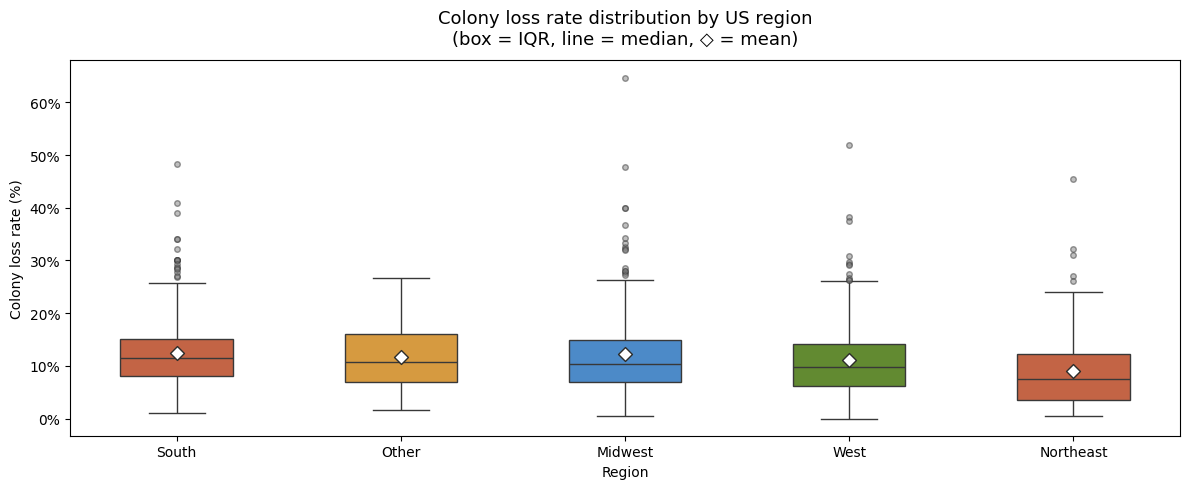

In [77]:
fig, ax = plt.subplots(figsize=(12,5))
region_order = (
    df_clean.groupby('Region')['loss_rate']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.boxplot(
    data=df_clean,
    x='Region',
    y='loss_rate',
    order=region_order,
    palette=['#D85A30', '#EF9F27', '#378ADD', '#639922'],
    width=0.5,
    linewidth=1,
    flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=4, alpha=0.5),
    ax=ax,
)

region_means = df_clean.groupby('Region')['loss_rate'].mean()
for i, region in enumerate(region_order):
    ax.scatter(i, region_means[region], marker='D',
               color='white', s=50, zorder=5, linewidths=1,
               edgecolors='#2C2C2A')

ax.set_title('Colony loss rate distribution by US region\n(box = IQR, line = median, ◇ = mean)',
             fontsize=13, pad=12)
ax.set_xlabel('Region')
ax.set_ylabel('Colony loss rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig('day2_regional_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [78]:
df_clean['year_extract'] = df_clean['Year'].str.extract(r'(\d{4})')
seasonal_trend = (
    df_clean
    .groupby(['year_extract', 'Season'])['loss_rate']
    .mean()
    .reset_index()
)
pivot_trend = seasonal_trend.pivot(
    index='year_extract',
    columns='Season',
    values='loss_rate'
)
pivot_trend = pivot_trend.reindex(season_order, axis=1)
pivot_trend.head()

Season,Winter,Spring,Summer,Fall
year_extract,,,,
2015,17.873458,8.684905,11.291367,10.220849
2016,13.708796,8.731357,11.044359,10.977075
2017,15.067906,7.064345,12.377837,12.375544
2018,16.694501,8.773723,11.071137,13.401562
2019,12.746907,NaN,11.057842,11.748686


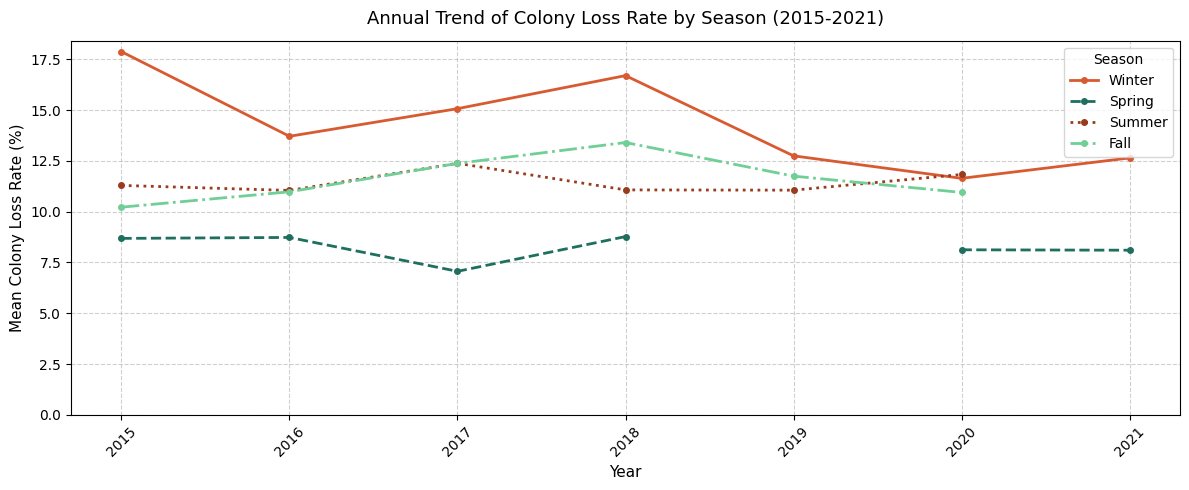

In [79]:
fig, ax = plt.subplots(figsize=(12,5))

line_styles = {'Winter': '-', 'Spring': '--', 'Summer': ':', 'Fall': '-.'}
colors = {'Winter': '#D85A30', 'Spring': '#1F6F5F', 'Summer': '#993C1D', 'Fall': '#6FCF97'}

for season in season_order:
    ax.plot(pivot_trend.index, pivot_trend[season], label=season,
            linestyle=line_styles.get(season, '-'), color=colors.get(season, 'black'),
            marker='o', markersize=4, linewidth=2)

ax.set_title('Annual Trend of Colony Loss Rate by Season (2015-2021)', fontsize=13, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean Colony Loss Rate (%)', fontsize=11)
ax.legend(title='Season', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('day2_seasonal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis of Seasonal Trends in Colony Loss Rate

The line plot above illustrates the mean colony loss rate for each season (Winter, Spring, Summer, Fall) over the years 2015-2021. Several key observations can be drawn from this trend:

*   **Winter has consistently the highest loss rate:** This is expected as bees face significant challenges during colder months, including food scarcity, harsh weather, and increased susceptibility to diseases.

*   **Spring has the lowest loss rate:** This period generally marks the beginning of blooming flowers and increased food availability, allowing colonies to rebound and grow.

*   **Relatively stable trends for Summer and Fall:** 'Summer' and 'Fall' loss rates tend to fall between Winter and Spring, often showing more moderate fluctuations.

*   **Overall Fluctuations:** While the seasonal patterns are clear, there are year-to-year variations within each season. For instance, some years show slightly higher or lower loss rates within a given season compared to others. This could be attributed to varying environmental conditions, disease prevalence, or beekeeping practices in those specific years.

*   **No clear long-term improvement or decline within this period:** For the observed period (2015-2021), there isn't a strong indication of a sustained, significant decrease or increase in colony loss rates for any particular season. The trends appear relatively stable, oscillating around a mean for each season.

## STRESSOR CORRELATION MATRIX

In [80]:
df_stressor = pd.read_csv('NASS_Bee-Stressors_2015-2021.csv', low_memory=False)

In [81]:
print('df_stressor info:')
df_stressor.info()

df_stressor['year_extract'] = df_stressor['Year'].str.extract(r'(\d{4})')

print('\nStressors DataFrame head after year extraction:')
display(df_stressor.head())

df_stressor info:
<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   State                                1175 non-null   str  
 1   Varroa Mites (Percent)               1175 non-null   str  
 2   Other pests and parasites (Percent)  1175 non-null   str  
 3   Diseases (percent)                   1175 non-null   str  
 4   Pesticides (percent)                 1175 non-null   str  
 5   Other (percent)                      1175 non-null   str  
 6   Unknown (percent)                    1175 non-null   str  
 7   Year                                 1175 non-null   str  
dtypes: str(8)
memory usage: 73.6 KB

Stressors DataFrame head after year extraction:


,State,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent),Year,year_extract
0,Alabama,10,5.4,(Z),2.2,9.1,9.4,2015-Q1,2015
1,Arizona,26.9,20.5,0.1,(Z),1.8,3.1,2015-Q1,2015
2,Arkansas,17.6,11.4,1.5,3.4,1,1,2015-Q1,2015
3,California,24.7,7.2,3,7.5,6.5,2.8,2015-Q1,2015
4,Colorado,14.6,0.9,1.8,0.6,2.6,5.9,2015-Q1,2015


In [82]:
df_merged = pd.merge(df_clean, df_stressor, on=['State', 'Year'], how='inner', suffixes=('_colony', '_stressor'))

print('Merged DataFrame head:')
display(df_merged.head())

Merged DataFrame head:


,State,Starting Colonies,Maximum Colonies,Lost Colonies,Percent Loss,Added Colonies,Renovated Colonies,Percent Renovated,Year,loss_rate,...,Season,Region,year_extract_colony,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent),year_extract_stressor
0,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,...,Winter,South,2015,10,5.4,(Z),2.2,9.1,9.4,2015
1,Arizona,35000.0,35000.0,4600.0,13.0,3400.0,2100.0,6.0,2015-Q1,13.142857,...,Winter,West,2015,26.9,20.5,0.1,(Z),1.8,3.1,2015
2,Arkansas,13000.0,14000.0,1500.0,11.0,1200.0,90.0,1.0,2015-Q1,10.714286,...,Winter,South,2015,17.6,11.4,1.5,3.4,1,1,2015
3,California,1440000.0,1690000.0,255000.0,15.0,250000.0,124000.0,7.0,2015-Q1,15.088757,...,Winter,West,2015,24.7,7.2,3,7.5,6.5,2.8,2015
4,Colorado,3500.0,12500.0,1500.0,12.0,200.0,140.0,1.0,2015-Q1,12.000000,...,Winter,West,2015,14.6,0.9,1.8,0.6,2.6,5.9,2015


In [83]:
print(f"Shape of merged DataFrame: {df_merged.shape}")

print('\nMissing values in merged DataFrame:')
print(df_merged.isna().sum().sort_values(ascending=False).head(10))

Shape of merged DataFrame: (1098, 21)

Missing values in merged DataFrame:
Percent Renovated     128
Starting Colonies       0
Maximum Colonies        0
Lost Colonies           0
State                   0
Percent Loss            0
Added Colonies          0
Renovated Colonies      0
Year                    0
loss_rate               0
dtype: int64


In [84]:
stressor_cols = [
    'Varroa Mites (Percent)', 'Other pests and parasites (Percent)',
    'Diseases (percent)', 'Pesticides (percent)', 'Other (percent)',
    'Unknown (percent)'
]

# Convert stressor columns to numeric, coercing errors
for col in stressor_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

print('Stressor columns dtypes after conversion:')
print(df_merged[stressor_cols].dtypes)

Stressor columns dtypes after conversion:
Varroa Mites (Percent)                 float64
Other pests and parasites (Percent)    float64
Diseases (percent)                     float64
Pesticides (percent)                   float64
Other (percent)                        float64
Unknown (percent)                      float64
dtype: object


In [85]:
correlation_data = df_merged[['loss_rate'] + stressor_cols]

correlation_matrix = correlation_data.corr()

print('\nCorrelation Matrix:')
display(correlation_matrix)


Correlation Matrix:


,loss_rate,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent)
loss_rate,1.000000,0.210014,0.043913,0.132979,0.140703,0.319755,0.272517
Varroa Mites (Percent),0.210014,1.000000,0.540236,0.325957,0.431683,0.299368,0.157386
Other pests and parasites (Percent),0.043913,0.540236,1.000000,0.235522,0.321326,0.197397,0.178445
Diseases (percent),0.132979,0.325957,0.235522,1.000000,0.328304,0.269647,0.082109
Pesticides (percent),0.140703,0.431683,0.321326,0.328304,1.000000,0.339096,0.187419
Other (percent),0.319755,0.299368,0.197397,0.269647,0.339096,1.000000,0.213500
Unknown (percent),0.272517,0.157386,0.178445,0.082109,0.187419,0.213500,1.000000


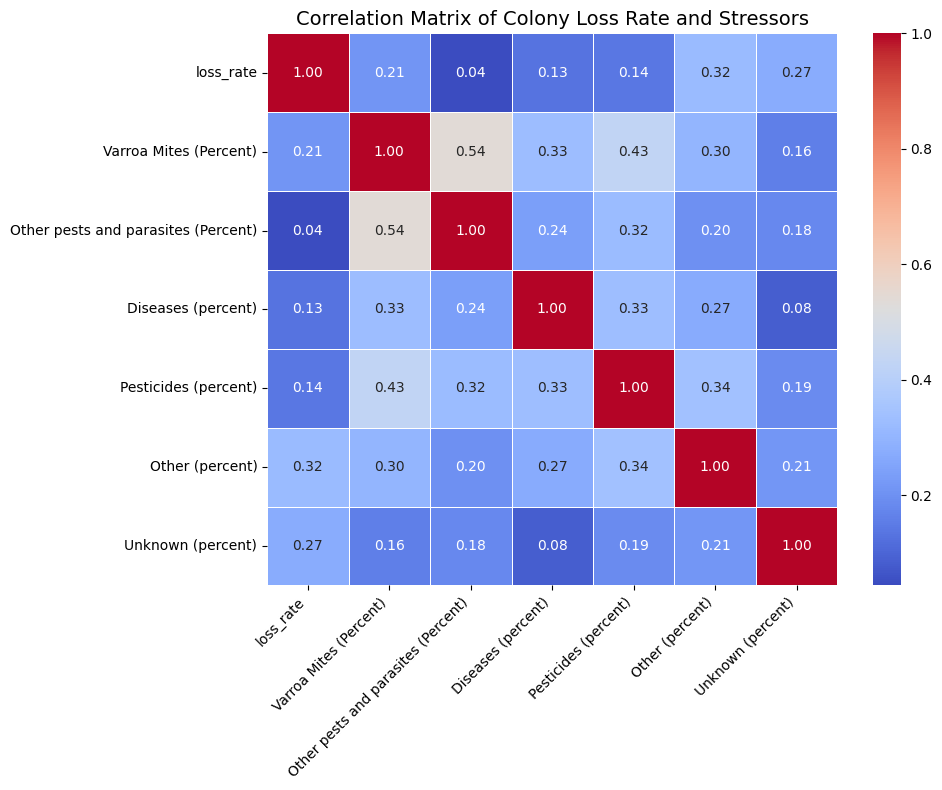

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Colony Loss Rate and Stressors', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('day3_stressor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [87]:
from scipy import stats
for s in stressor_cols:
  temp = df_merged[[s, 'loss_rate']].dropna()
  r,p = stats.pearsonr(temp[s], temp['loss_rate'])
  sig = '*' if p < 0.05 else ''
  print(f'{s}: r = {r:.2f} {sig}')


Varroa Mites (Percent): r = 0.21 *
Other pests and parasites (Percent): r = 0.04 
Diseases (percent): r = 0.13 *
Pesticides (percent): r = 0.14 *
Other (percent): r = 0.32 *
Unknown (percent): r = 0.27 *


- Varroa Mites shows the strongest correlation with colony_loss (0.13) meaning states with higher verroa infection rates consistently lose more colony.
- Pest and parasites presence shows the weakest positive correlation (r = 0.03) showing a small but statistically significant relationship with colony loss.
-

## Regression model

In [88]:
# One-hot encode Season and Region
season_dummies = pd.get_dummies(df_merged['Season'], prefix='Season', drop_first=True)
region_dummies = pd.get_dummies(df_merged['Region'], prefix='Region', drop_first=True)

target = 'loss_rate'
feature_df = pd.concat([df_merged[stressor_cols + [target]], season_dummies, region_dummies], axis=1)
model_df = feature_df.dropna(subset=stressor_cols + [target])

features = stressor_cols + list(season_dummies.columns) + list(region_dummies.columns)
X = model_df[features]
y = model_df[target]

In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (712, 13)
Testing data shape: (178, 13)


In [90]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [91]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {mse:.2f}")


R-squared: 0.31
Mean Absolute Error: 4.20
Root Mean Squared Error: 5.62


In [92]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest R²  : {r2_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest MAE : {mean_absolute_error(y_test, y_pred_rf):.2f}%")

# Feature importance — more reliable than linear coefficients
importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

Random Forest R²  : 0.460
Random Forest MAE : 3.74%
                                feature  importance
4                       Other (percent)    0.187498
0                Varroa Mites (Percent)    0.182044
5                     Unknown (percent)    0.171174
2                    Diseases (percent)    0.113000
1   Other pests and parasites (Percent)    0.103456
3                  Pesticides (percent)    0.095990
8                         Season_Winter    0.076237
6                         Season_Spring    0.026729
9                      Region_Northeast    0.011997
12                          Region_West    0.011173
11                         Region_South    0.009219
7                         Season_Summer    0.006797
10                         Region_Other    0.004688


── Top 15 most important features ──────────────────────
                            feature  importance
                    Other (percent)    0.187498
             Varroa Mites (Percent)    0.182044
                  Unknown (percent)    0.171174
                 Diseases (percent)    0.113000
Other pests and parasites (Percent)    0.103456
               Pesticides (percent)    0.095990
                      Season_Winter    0.076237
                      Season_Spring    0.026729
                   Region_Northeast    0.011997
                        Region_West    0.011173
                       Region_South    0.009219
                      Season_Summer    0.006797
                       Region_Other    0.004688


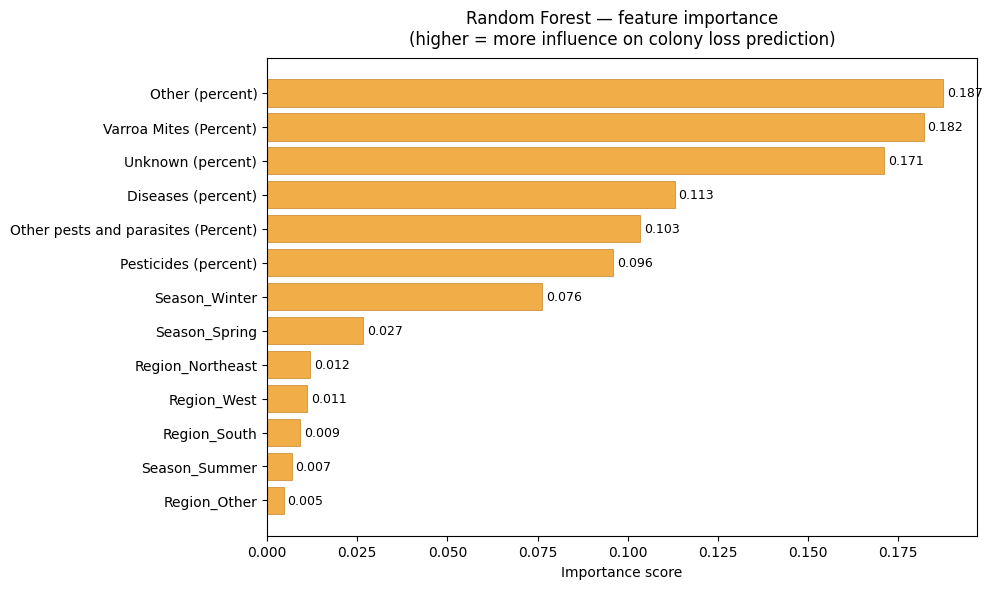

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("── Top 15 most important features ──────────────────────")
print(importance_df.head(15).to_string(index=False))

# Plot top 15
top15 = importance_df.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15['feature'],
    top15['importance'],
    color='#EF9F27',
    edgecolor='#BA7517',
    linewidth=0.5,
    alpha=0.85,
)

# Add value labels
for bar, val in zip(bars, top15['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Random Forest — feature importance\n(higher = more influence on colony loss prediction)',
             fontsize=12, pad=10)
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('day4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


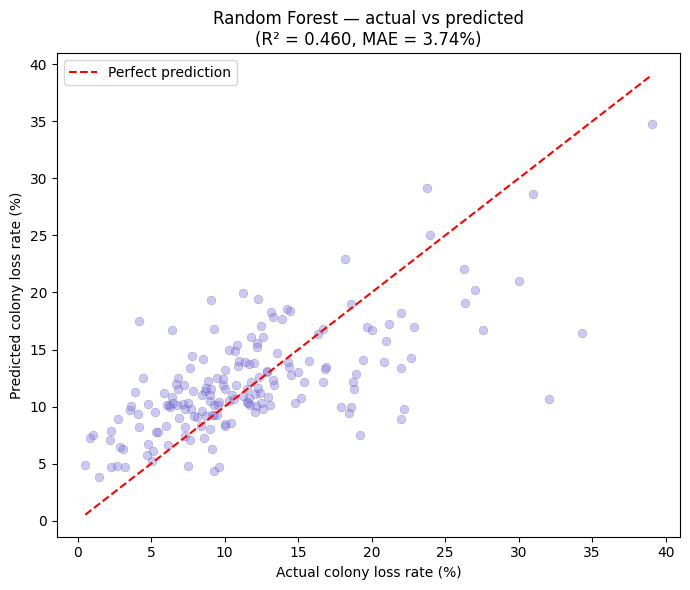

In [96]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred_rf,
           alpha=0.4, color='#7F77DD',
           edgecolors='#3C3489', linewidth=0.3, s=40)

# Perfect prediction line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual colony loss rate (%)')
ax.set_ylabel('Predicted colony loss rate (%)')
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

ax.set_title(
    f'Random Forest — actual vs predicted\n(R² = {r2_rf:.3f}, MAE = {mae_rf:.2f}%)',
    fontsize=12
)
ax.legend()
plt.tight_layout()
plt.savefig('day4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 5: Final visualization

In [97]:
import plotly.express as px
import plotly.graph_objects as go
 
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df_merged.to_csv("bee_colony_loss.csv", index = False)


In [98]:
df = pd.read_csv("bee_colony_loss.csv", low_memory = False)
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRegions: {sorted(df['Region'].dropna().unique())}")
print(f"Seasons: {sorted(df['Season'].dropna().unique())}")
 
 

Data loaded: 1,098 rows × 21 columns
Columns: ['State', 'Starting Colonies', 'Maximum Colonies', 'Lost Colonies', 'Percent Loss', 'Added Colonies', 'Renovated Colonies', 'Percent Renovated', 'Year', 'loss_rate', 'quarter_label', 'Season', 'Region', 'year_extract_colony', 'Varroa Mites (Percent)', 'Other pests and parasites (Percent)', 'Diseases (percent)', 'Pesticides (percent)', 'Other (percent)', 'Unknown (percent)', 'year_extract_stressor']

Regions: ['Midwest', 'Northeast', 'Other', 'South', 'West']
Seasons: ['Fall', 'Spring', 'Summer', 'Winter']


In [101]:
state_avg = (
    df.groupby('State')['loss_rate']
    .agg(mean_loss='mean', median_loss='median', count='count')
    .reset_index()
    .sort_values('mean_loss', ascending=False)
)
 
# ── Regional averages by year (for trend chart) 
if 'year_extract' not in df.columns:
    df['year_extract'] = df['Year'].astype(str).str.extract(r'(\d{4})')

regional_trend = (
    df.groupby(['year_extract', 'Region'])['loss_rate']
    .mean()
    .reset_index()
    .rename(columns={'loss_rate': 'mean_loss'})
)
 
# ── Stressor columns (for stacked bar) ──────────────────
# Identify stressor columns automatically
stressor_cols = [c for c in df.columns if any(
    x in c.lower() for x in
    ['varroa', 'pest', 'disease', 'pesticide', 'unknown', 'other']
) and c != 'loss_rate']
 
print(f"\nStressor columns detected: {stressor_cols}")
 
# Regional stressor averages
if len(stressor_cols) > 0:
    regional_stressors = (
        df.groupby('Region')[stressor_cols]
        .mean()
        .reset_index()
    )
else:
    print("WARNING: No stressor columns found — stacked bar chart will be skipped")
    regional_stressors = None
 
# ── Quarter-level pivot for heatmap 
# Build state × period heatmap data
if 'months' in df.columns:
    period_col = 'months'
elif 'Period' in df.columns:
    period_col = 'Period'
else:
    period_col = df.columns[2]   
 
heatmap_pivot = pd.pivot_table(
    df,
    index='State',
    columns= 'quarter_label',
    values='loss_rate',
    aggfunc='mean'
).round(1)
 
print(f"\nHeatmap pivot shape: {heatmap_pivot.shape}")
print(f"State averages computed: {len(state_avg)} states")
print(f"Regional trend rows: {len(regional_trend)}")
 
 


Stressor columns detected: ['Varroa Mites (Percent)', 'Other pests and parasites (Percent)', 'Diseases (percent)', 'Pesticides (percent)', 'Other (percent)', 'Unknown (percent)']

Heatmap pivot shape: (46, 4)
State averages computed: 46 states
Regional trend rows: 35


In [102]:
STATE_ABBREV = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ',
    'Arkansas': 'AR', 'California': 'CA', 'Colorado': 'CO',
    'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA',
    'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY',
}
 
state_avg['state_abbrev'] = state_avg['State'].map(STATE_ABBREV)
 
state_map_data = state_avg.dropna(subset=['state_abbrev']).copy()
state_map_data['mean_loss'] = state_map_data['mean_loss'].round(1)
 
# Build the choropleth
fig_map = px.choropleth(
    state_map_data,
    locations='state_abbrev',          
    locationmode='USA-states',         
    color='mean_loss',                  
    scope='usa',                        
    color_continuous_scale=[            
        [0.0,  '#FFF9F0'],
        [0.3,  '#FAEEDA'],
        [0.6,  '#EF9F27'],
        [0.8,  '#D85A30'],
        [1.0,  '#7A1A00'],
    ],
    hover_name='State',                
    hover_data={
        'state_abbrev': False,          
        'mean_loss': ':.1f',            
        'count': True,                  
    },
    labels={'mean_loss': 'Avg loss rate (%)'},
    title='Average honey bee colony loss rate by US state (2015–2021)',
)
 
fig_map.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    coloraxis_colorbar=dict(
        title='Loss rate (%)',
        ticksuffix='%',
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    height=500,
)
 
fig_map.show()
 
# Save as interactive HTML 
fig_map.write_html('day5_us_map.html')
print("Interactive map saved: day5_us_map.html")
print("Open it in your browser to hover over states.")
print(f"\nHighest loss: {state_map_data.iloc[0]['State']} ({state_map_data.iloc[0]['mean_loss']:.1f}%)")
print(f"Lowest loss : {state_map_data.iloc[-1]['State']} ({state_map_data.iloc[-1]['mean_loss']:.1f}%)")

Interactive map saved: day5_us_map.html
Open it in your browser to hover over states.

Highest loss: Kansas (19.9%)
Lowest loss : Hawaii (5.4%)


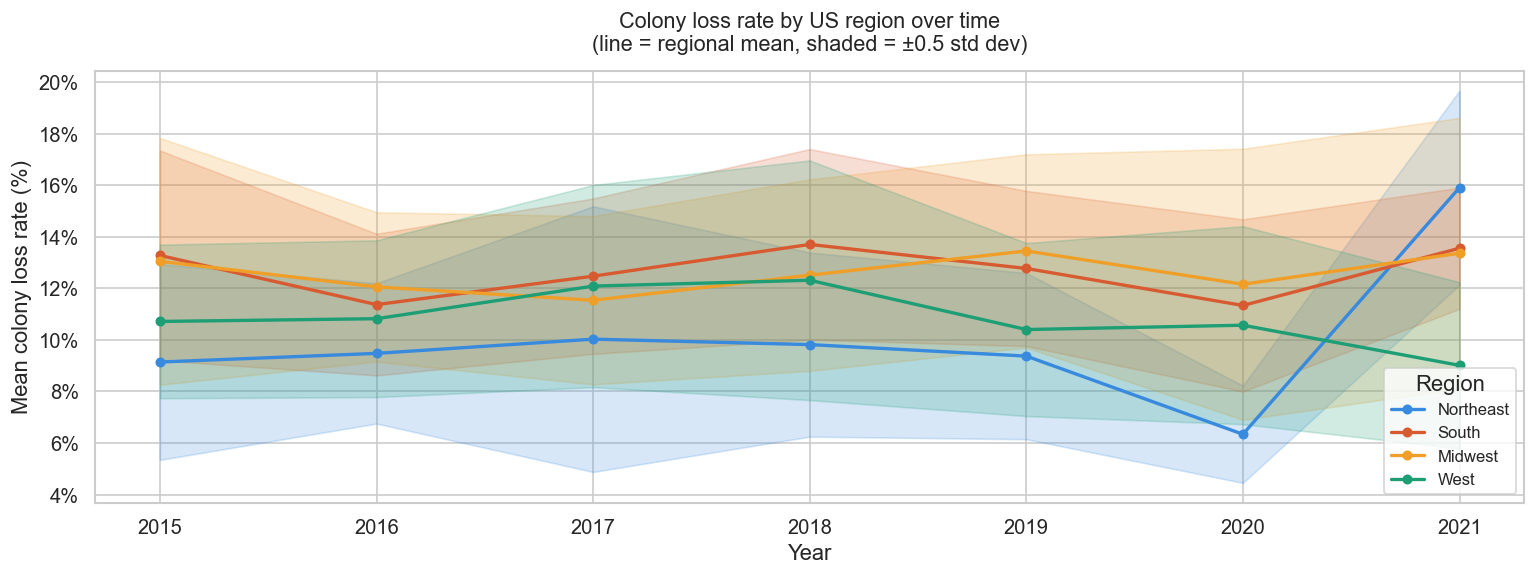

Chart saved: day5_trend_by_region.png


In [105]:
REGION_COLORS = {
    'Northeast': '#378ADD',
    'South':     '#D85A30',
    'Midwest':   '#EF9F27',
    'West':      '#1D9E75',
}
 
# compute standard deviation for confidence interval
regional_trend_std = (
    df.groupby(['year_extract', 'Region'])['loss_rate']
    .std()
    .reset_index()
    .rename(columns={'loss_rate': 'std_loss'})
)
 
regional_trend = regional_trend.merge(regional_trend_std,
                                       on=['year_extract', 'Region'])
 
fig, ax = plt.subplots(figsize=(13, 5))
 
for region, color in REGION_COLORS.items():
    sub = regional_trend[regional_trend['Region'] == region].sort_values('year_extract')
    if len(sub) == 0:
        continue
 
    ax.plot(sub['year_extract'], sub['mean_loss'],
            marker='o', markersize=5,
            linewidth=2, color=color, label=region)
 
    # mean ± 0.5 std
    ax.fill_between(sub['year_extract'], 
                     sub['mean_loss'] - 0.5 * sub['std_loss_x'],
                     sub['mean_loss'] + 0.5 * sub['std_loss_x'],
                     alpha=0.2, color=color)
 
ax.set_title('Colony loss rate by US region over time\n(line = regional mean, shaded = ±0.5 std dev)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Mean colony loss rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(title='Region', fontsize=10)
ax.set_xticks(regional_trend['year_extract'].unique())
 
plt.tight_layout()
plt.savefig('day5_trend_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Chart saved: day5_trend_by_region.png")


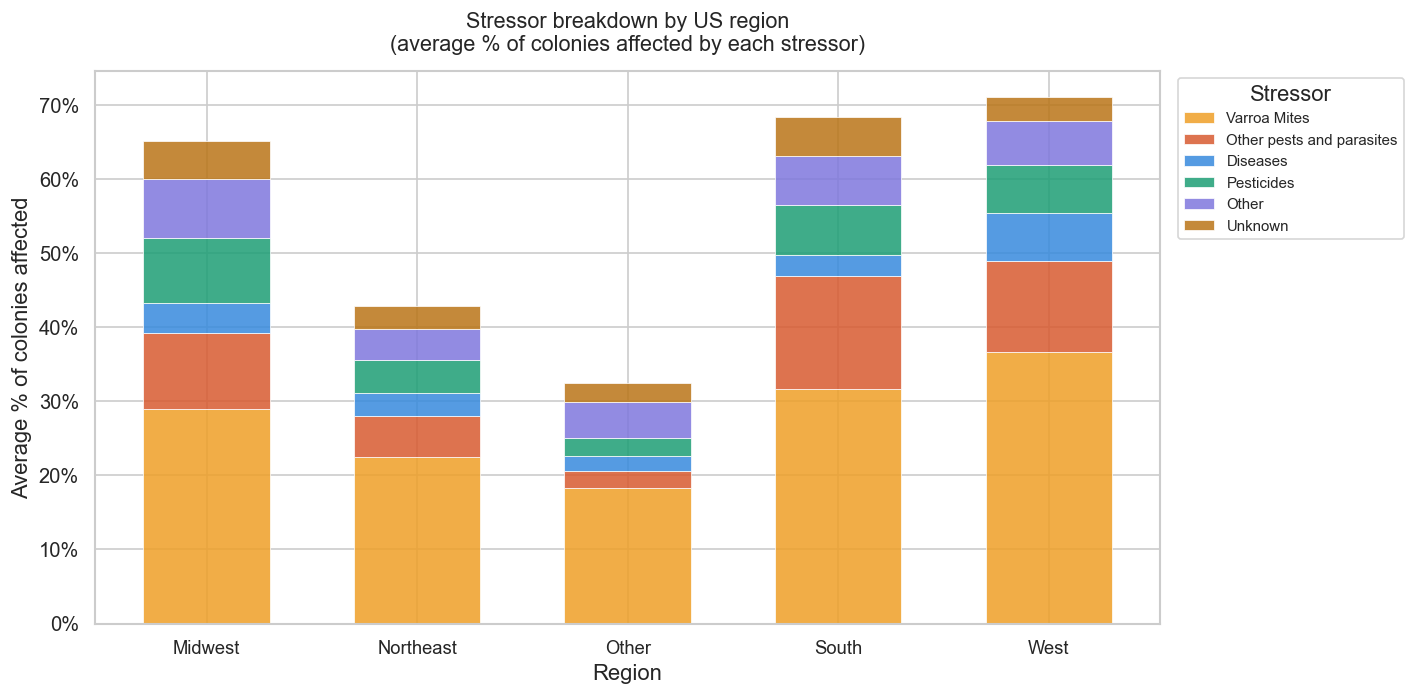

Chart saved: tressor_stack.png


In [109]:
if regional_stressors is not None and len(stressor_cols) > 0:
     
    clean_names = {
        col: col.replace('(Percent)', '').replace('(percent)', '')
                .replace('_', ' ').strip()
        for col in stressor_cols
    }
 
    STRESSOR_COLORS = [
        '#EF9F27',  # Amber
        '#D85A30',  # Coral
        '#378ADD',  # Blue
        '#1D9E75',  # Green
        '#7F77DD',  # Purple
        '#BA7517',  # Dark amber
    ]
 
    regions = regional_stressors['Region'].tolist()
    x = np.arange(len(regions))
    bottoms = np.zeros(len(regions))
 
    fig, ax = plt.subplots(figsize=(12, 6))
 
    for i, col in enumerate(stressor_cols):
        values = regional_stressors[col].fillna(0).values
        color  = STRESSOR_COLORS[i % len(STRESSOR_COLORS)]
        ax.bar(x, values, bottom=bottoms,
               label=clean_names[col],
               color=color, alpha=0.85,
               edgecolor='white', linewidth=0.5, width=0.6)
        bottoms += values
 
    ax.set_title('Stressor breakdown by US region\n(average % of colonies affected by each stressor)',
                 fontsize=13, pad=12)
    ax.set_xlabel('Region')
    ax.set_ylabel('Average % of colonies affected')
    ax.set_xticks(x)
    ax.set_xticklabels(regions, fontsize=11)
    ax.legend(title='Stressor', bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
 
    plt.tight_layout()
    plt.show()
 
    print("Chart saved: tressor_stack.png")
    
 

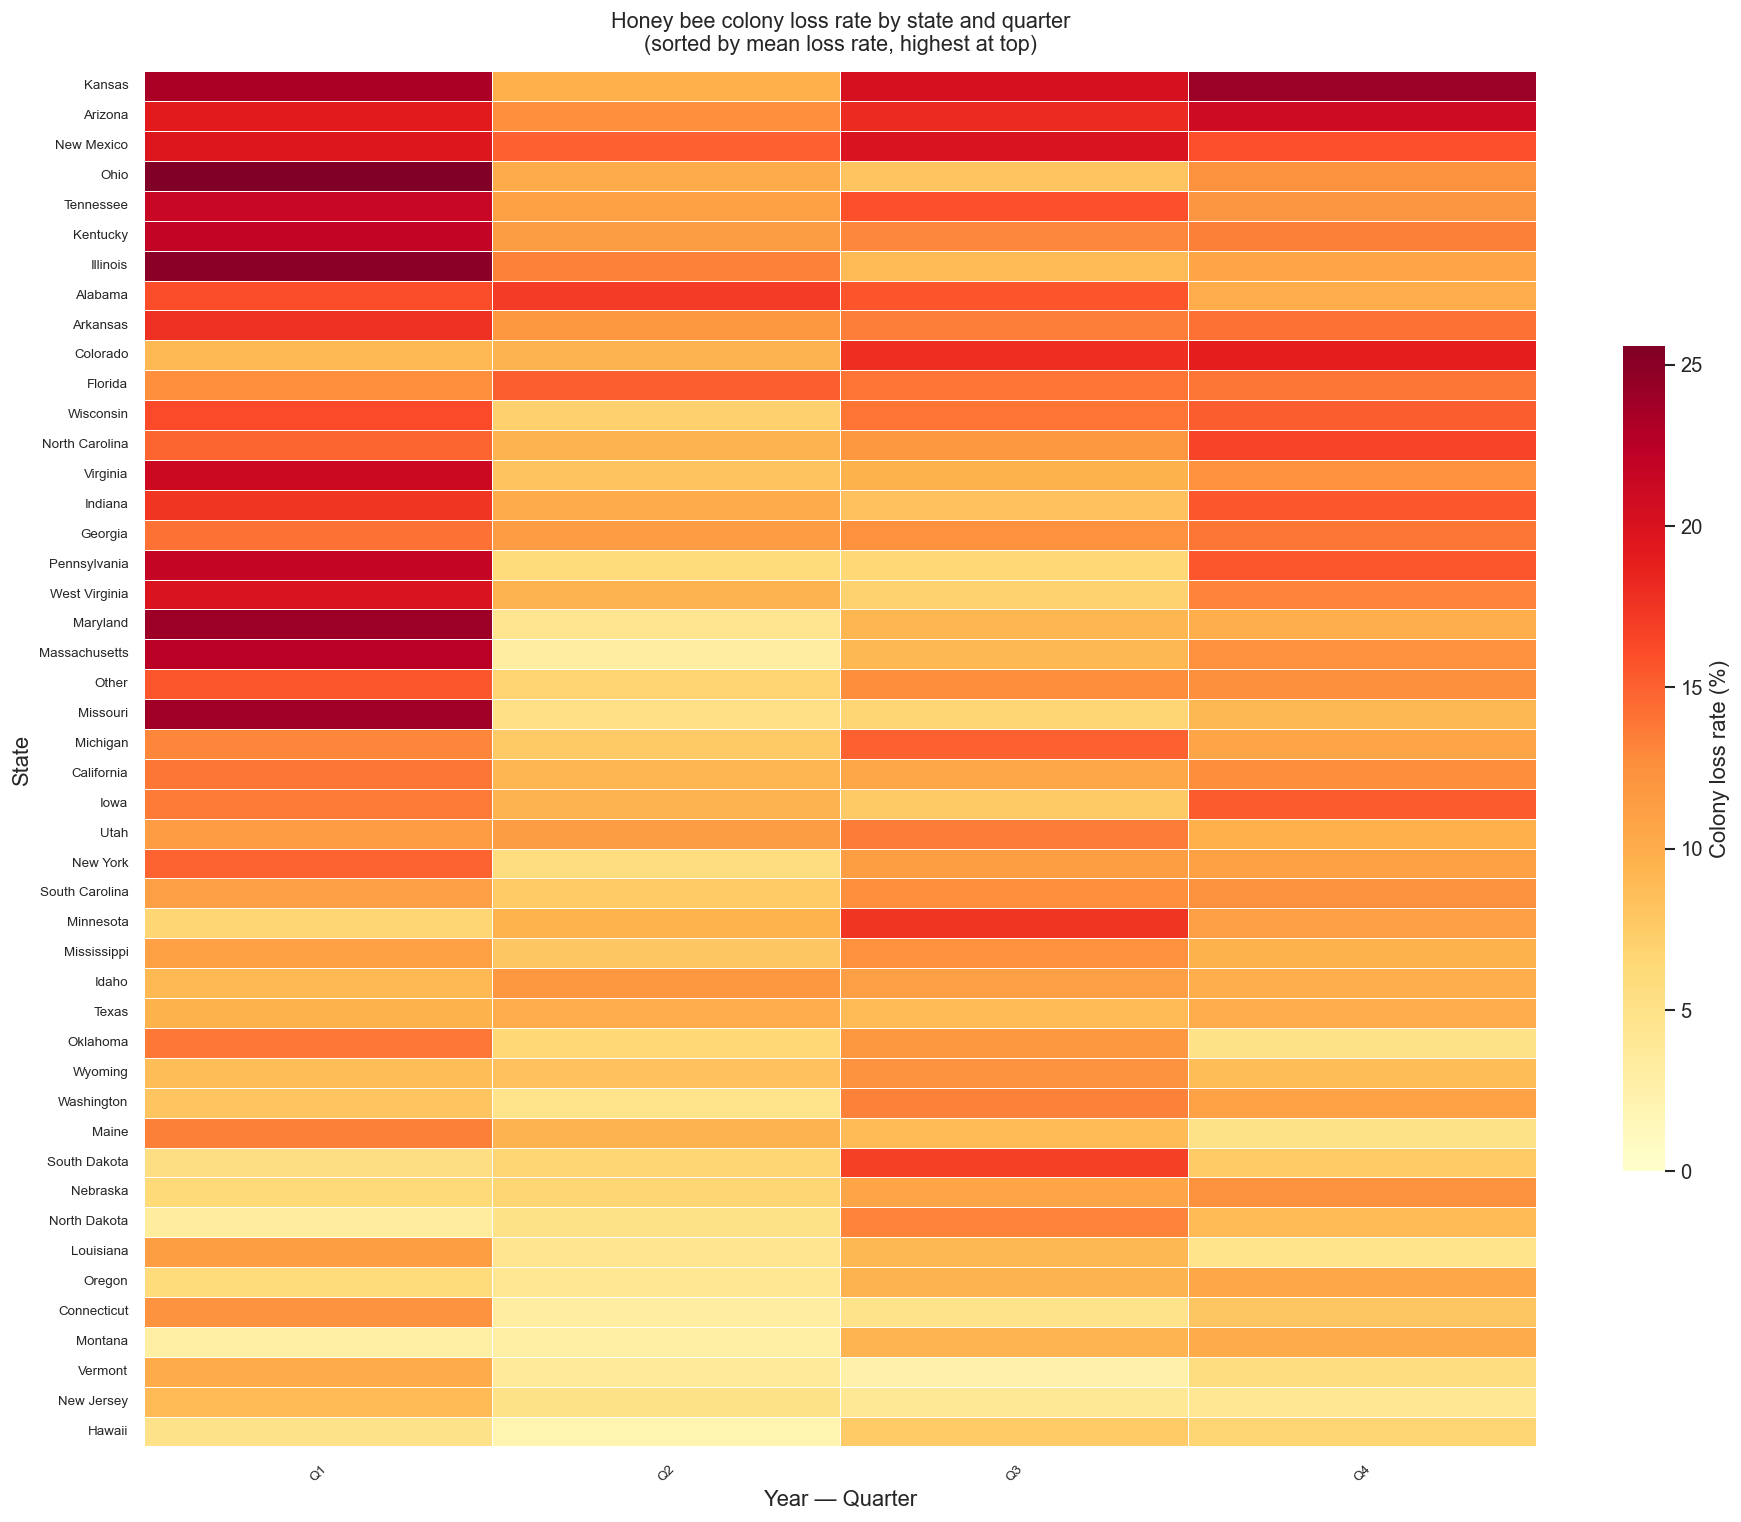

In [ ]:
state_order = (
    df.groupby('State')['loss_rate']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
 
heatmap_sorted = heatmap_pivot.reindex(state_order)
 
heatmap_sorted = heatmap_sorted.dropna(thresh=int(heatmap_sorted.shape[1] * 0.5))
 
fig, ax = plt.subplots(figsize=(16, max(8, len(heatmap_sorted) * 0.28)))
 
sns.heatmap(
    heatmap_sorted,
    ax=ax,
    cmap='YlOrRd',           # Yellow → Orange → Red (low → high loss)
    linewidths=0.3,
    linecolor='white',
    annot=len(heatmap_sorted) <= 25,  # Only annotate if not too many rows
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Colony loss rate (%)', 'shrink': 0.6},
    vmin=0,
    vmax=df['loss_rate'].quantile(0.95),  # Cap at 95th percentile for colour scale
)
 
ax.set_title('Honey bee colony loss rate by state and quarter\n(sorted by mean loss rate, highest at top)',
             fontsize=13, pad=12)
ax.set_xlabel('Year — Quarter')
ax.set_ylabel('State')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
 
plt.tight_layout()
plt.show()
 

In [ ]:
state_summary = state_avg.copy()
state_summary['rank'] = state_summary['mean_loss'].rank(
    ascending=False).astype(int)
state_summary['mean_loss'] = state_summary['mean_loss'].round(2)
state_summary['median_loss'] = state_summary['median_loss'].round(2)
 
# region
STATE_REGION_MAP = {
    'Connecticut':'Northeast','Maine':'Northeast','Massachusetts':'Northeast',
    'New Hampshire':'Northeast','Rhode Island':'Northeast','Vermont':'Northeast',
    'New Jersey':'Northeast','New York':'Northeast','Pennsylvania':'Northeast',
    'Delaware':'South','Florida':'South','Georgia':'South','Maryland':'South',
    'North Carolina':'South','South Carolina':'South','Virginia':'South',
    'West Virginia':'South','Alabama':'South','Kentucky':'South',
    'Mississippi':'South','Tennessee':'South','Arkansas':'South',
    'Louisiana':'South','Oklahoma':'South','Texas':'South',
    'Illinois':'Midwest','Indiana':'Midwest','Michigan':'Midwest',
    'Ohio':'Midwest','Wisconsin':'Midwest','Iowa':'Midwest','Kansas':'Midwest',
    'Minnesota':'Midwest','Missouri':'Midwest','Nebraska':'Midwest',
    'North Dakota':'Midwest','South Dakota':'Midwest',
    'Arizona':'West','Colorado':'West','Idaho':'West','Montana':'West',
    'Nevada':'West','New Mexico':'West','Utah':'West','Wyoming':'West',
    'Alaska':'West','California':'West','Hawaii':'West',
    'Oregon':'West','Washington':'West',
}
state_summary['Region'] = state_summary['State'].map(STATE_REGION_MAP)
 
display_cols = ['rank', 'State', 'Region', 'mean_loss', 'median_loss', 'count']
state_display = state_summary[display_cols].rename(columns={
    'rank':       'Rank',
    'State':      'State',
    'Region':     'Region',
    'mean_loss':  'Mean Loss (%)',
    'median_loss':'Median Loss (%)',
    'count':      'Records',
})
 
print("── Full state summary table ─────────────────────────────────")
print(state_display.to_string(index=False))
 
styled = (
    state_display.style
    .background_gradient(
        subset=['Mean Loss (%)'],
        cmap='YlOrRd',       # Yellow → Red for loss rate
        vmin=state_display['Mean Loss (%)'].min(),
        vmax=state_display['Mean Loss (%)'].max(),
    )
    .format({'Mean Loss (%)': '{:.2f}', 'Median Loss (%)': '{:.2f}'})
    .set_caption('Honey Bee Colony Loss Rate by US State (2015–2021)')
)
 
styled.to_html('day5_state_summary.html')
print("\nStyled summary table saved: day5_state_summary.html")
print("Open in your browser to see colour-coded loss rates.")
 
 

── Full state summary table ─────────────────────────────────
 Rank          State    Region  Mean Loss (%)  Median Loss (%)  Records
    1         Kansas   Midwest          19.90            19.86       24
    2        Arizona      West          17.97            17.59       24
    3     New Mexico      West          17.82            17.03       24
    4           Ohio   Midwest          15.63            11.30       24
    5      Tennessee     South          15.54            14.56       24
    6       Kentucky     South          15.32            12.80       24
    7       Illinois   Midwest          14.92            12.79       24
    8        Alabama     South          14.63            11.91       24
    9       Arkansas     South          14.54            10.65       24
   10       Colorado      West          13.80            11.83       24
   11        Florida     South          13.79            13.60       24
   12      Wisconsin   Midwest          13.48            14.02       24
  